In [2]:
from google.colab import files

uploaded = files.upload()

Saving 관광소비_폐업수_분석용_2023_2025.csv to 관광소비_폐업수_분석용_2023_2025.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
# 데이터 불러오기

df = pd.read_csv(
    "관광소비_폐업수_분석용_2023_2025.csv",
    encoding="utf-8-sig"
)

print("데이터 크기:", df.shape)
print("\n컬럼명:")
print(df.columns.tolist())

print("\n데이터 미리보기:")
display(df.head())

데이터 크기: (48, 6)

컬럼명:
['행정구', '연도', '현지인 관광소비액(만원)', '외지인 관광소비액(만원)', '외국인 관광소비액(만원)', '폐업수']

데이터 미리보기:


,행정구,연도,현지인 관광소비액(만원),외지인 관광소비액(만원),외국인 관광소비액(만원),폐업수
0,강서구,2023,519363,75780511,1621782,3755
1,금정구,2023,1630295,29911626,373546,3645
2,기장군,2023,656326,93094637,3668080,3429
3,남구,2023,411158,37818510,1924294,4104
4,동구,2023,348419,34024491,2915874,2212


In [5]:
# 데이터 기본 확인

print("===== 데이터 정보 =====")
df.info()

print("\n===== 결측치 =====")
print(df.isnull().sum())

print("\n===== 중복 행 =====")
print(df.duplicated().sum())

print("\n===== 행정구 수 =====")
print(df["행정구"].nunique())

print("\n===== 연도 =====")
print(sorted(df["연도"].unique()))

===== 데이터 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   행정구            48 non-null     object
 1   연도             48 non-null     int64 
 2   현지인 관광소비액(만원)  48 non-null     int64 
 3   외지인 관광소비액(만원)  48 non-null     int64 
 4   외국인 관광소비액(만원)  48 non-null     int64 
 5   폐업수            48 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 2.4+ KB

===== 결측치 =====
행정구              0
연도               0
현지인 관광소비액(만원)    0
외지인 관광소비액(만원)    0
외국인 관광소비액(만원)    0
폐업수              0
dtype: int64

===== 중복 행 =====
0

===== 행정구 수 =====
16

===== 연도 =====
[np.int64(2023), np.int64(2024), np.int64(2025)]


In [6]:
# 기초통계량 확인

df.describe().T

,count,mean,std,min,25%,50%,75%,max
연도,48.0,2.024000e+03,8.251370e-01,2023.0,2023.00,2024.0,2025.0,2025.0
현지인 관광소비액(만원),48.0,4.350895e+06,1.324084e+07,77761.0,208708.25,442247.5,946299.5,55236163.0
외지인 관광소비액(만원),48.0,5.791355e+07,4.191508e+07,9737699.0,32996274.75,44178076.0,86347080.5,178248074.0
외국인 관광소비액(만원),48.0,4.401807e+06,6.773198e+06,180284.0,438520.25,1773038.0,3783394.0,29913655.0
폐업수,48.0,3.664375e+03,1.645180e+03,1360.0,2969.25,3630.5,4057.0,8005.0


In [7]:
# Pearson 상관분석

# 상관계수 r

# + → 소비액이 증가할수록 폐업수가 증가하는 방향
# - → 소비액이 증가할수록 폐업수가 감소하는 방향
# 절댓값이 클수록 선형 관계가 강함

# ② p-value

# p < 0.05 → 통계적으로 유의한 관계
# p ≥ 0.05 → 통계적으로 유의하다고 보기 어려움

from scipy.stats import pearsonr

variables = [
    "현지인 관광소비액(만원)",
    "외지인 관광소비액(만원)",
    "외국인 관광소비액(만원)"
]

results = []

for var in variables:
    r, p = pearsonr(df[var], df["폐업수"])

    results.append({
        "관광소비 유형": var,
        "상관계수(r)": r,
        "p-value": p
    })

corr_result = pd.DataFrame(results)

display(corr_result)

,관광소비 유형,상관계수(r),p-value
0,현지인 관광소비액(만원),0.670033,1.901493e-07
1,외지인 관광소비액(만원),0.745974,1.168414e-09
2,외국인 관광소비액(만원),0.669487,1.961854e-07


In [8]:
# 관광소비유형	  r 	    p-value	        1차 해석
#   현지인	    0.670	    < 0.001	  유의한 양의 상관관계
#   외지인	    0.746	    < 0.001	  유의한 양의 상관관계
#   외국인	    0.669	    < 0.001	  유의한 양의 상관관계

# 세 관광소비액 모두 폐업수와 통계적으로 유의한 양의 선형 상관관계

In [9]:
# 단순선형회귀분석

# 독립변수
X_local = sm.add_constant(df["현지인 관광소비액(만원)"])
X_out = sm.add_constant(df["외지인 관광소비액(만원)"])
X_foreign = sm.add_constant(df["외국인 관광소비액(만원)"])

# 종속변수
y = df["폐업수"]

# 회귀모델
model_local = sm.OLS(y, X_local).fit()
model_out = sm.OLS(y, X_out).fit()
model_foreign = sm.OLS(y, X_foreign).fit()

print("===== 현지인 관광소비액 → 폐업수 =====")
print(model_local.summary())

print("\n===== 외지인 관광소비액 → 폐업수 =====")
print(model_out.summary())

print("\n===== 외국인 관광소비액 → 폐업수 =====")
print(model_foreign.summary())

===== 현지인 관광소비액 → 폐업수 =====
                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     37.48
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           1.90e-07
Time:                        07:30:24   Log-Likelihood:                -408.77
No. Observations:                  48   AIC:                             821.5
Df Residuals:                      46   BIC:                             825.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          330

In [10]:
# 회귀모형 분석

# 독립변수	  회귀계수 β	 p-value	     R²	  방향
#  현지인     관광소비액	8.325×10⁻⁵	<0.001	0.449	+
#  외지인     관광소비액	2.928×10⁻⁵	<0.001	0.556	+
#  외국인     관광소비액	약 2.0×10⁻⁴<0.001	 0.448 +

# 관광소비액이 증가할수록 폐업수가 증가하는 방향의 통계적으로 유의한 관계
# 외지인 > 외국인 ≈ 현지인

In [12]:
# 다중공선성 확인

# 일반적으로 VIF가 5를 넘는지, 특히 10 이상인지 등을 다중공선성의 경고 기준으로 활용

from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[
    [
        "현지인 관광소비액(만원)",
        "외지인 관광소비액(만원)",
        "외국인 관광소비액(만원)"
    ]
].copy()

X = sm.add_constant(X)

vif_result = pd.DataFrame()

vif_result["변수"] = X.columns
vif_result["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

display(vif_result)

,변수,VIF
0,const,4.340446
1,현지인 관광소비액(만원),2.892880
2,외지인 관광소비액(만원),2.769166
3,외국인 관광소비액(만원),2.210910


In [15]:
#         변수	      VIF  	판단
# 현지인 관광소비액	2.893	문제 없음
# 외지인 관광소비액	2.769	문제 없음
# 외국인 관광소비액	2.211	문제 없음

# 현지인·외지인·외국인 관광소비액을 하나의 다중회귀모형에 함께 넣어도 다중공선성이 심각한 문제라고 볼 근거가 없다

In [16]:
# 다중회귀분석
# 각 관광객 유형의 소비액을 서로 통제한 상태에서 각각 폐업수와 어떤 관계가 있는지 확인

# 독립변수
X = df[
    [
        "현지인 관광소비액(만원)",
        "외지인 관광소비액(만원)",
        "외국인 관광소비액(만원)"
    ]
]

# 상수항 추가
X = sm.add_constant(X)

# 종속변수
y = df["폐업수"]

# 다중회귀모형
model_multi = sm.OLS(y, X).fit()

print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     22.73
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           4.84e-09
Time:                        07:36:47   Log-Likelihood:                -400.61
No. Observations:                  48   AIC:                             809.2
Df Residuals:                      44   BIC:                             816.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2244.2153    320.193      7.009

In [17]:
# 관광소비 유형	회귀계수 β	p-value	        유의성
# 현지인	  0.00001515	      0.452	    ❌ 유의하지 않음
# 외지인	  0.00001865	      0.004	    ✅ 유의함
# 외국인	  0.00006231	      0.074	    ❌ 5% 기준 유의하지 않음

# R² = 0.608
# 수정 R² = 0.581
# F-test p-value < 0.001

# 입니다.

# 즉, 세 관광소비액을 함께 고려한 모델 자체는 통계적으로 유의

In [18]:
# 다른 관광소비 유형의 소비액을 통제하면 외지인 관광소비액만 5% 유의수준에서 폐업수와 유의한 관계가 남았습니다.

# 따라서 현재까지의 결과만 놓고 보면 외지인 관광소비액과 폐업수의 관계가 가장 일관되게 나타납니다.

In [19]:
df.groupby("행정구")["폐업수"].agg(
    ["mean", "min", "max"]
).sort_values("mean", ascending=False)

,mean,min,max
행정구,,,
해운대구,7414.666667,6938,8005
부산진구,7094.333333,6911,7315
동래구,4144.666667,4090,4195
사하구,3981.666667,3797,4102
남구,3912.000000,3676,4104
강서구,3909.333333,3755,4123
사상구,3730.000000,3533,3927
수영구,3691.000000,3515,3856
연제구,3624.333333,3609,3648


In [20]:
# 행정구 고정효과 회귀
model_fe_region = smf.ols(
    formula="""
    폐업수 ~
    Q("현지인 관광소비액(만원)") +
    Q("외지인 관광소비액(만원)") +
    Q("외국인 관광소비액(만원)") +
    C(행정구)
    """,
    data=df
).fit()

print(model_fe_region.summary())

                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     335.2
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           8.70e-29
Time:                        07:40:05   Log-Likelihood:                -294.85
No. Observations:                  48   AIC:                             627.7
Df Residuals:                      29   BIC:                             663.3
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           3713.0960   1070

In [21]:
# 변수	                계수	  p-value	  5% 유의수준
# 현지인 관광소비액	-0.0000879	0.380	        ❌
# 외지인 관광소비액	0.00000426	0.751	        ❌
# 외국인 관광소비액	-0.0000482	<0.001	      ✅

In [22]:
model_fe_tw = smf.ols(
    formula="""
    폐업수 ~
    Q("현지인 관광소비액(만원)") +
    Q("외지인 관광소비액(만원)") +
    Q("외국인 관광소비액(만원)") +
    C(행정구) +
    C(연도)
    """,
    data=df
).fit()

print(model_fe_tw.summary())

                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     361.4
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           9.95e-28
Time:                        07:42:20   Log-Likelihood:                -288.83
No. Observations:                  48   AIC:                             619.7
Df Residuals:                      27   BIC:                             659.0
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2349.3746   1105

In [23]:
# 현지인 관광소비액
# p = 0.269
# 통계적으로 유의하지 않음
# 따라서 현재 모델에서는 폐업수와 유의한 관계가 있다고 볼 수 없음

# 외지인 관광소비액
# p = 0.129
# 통계적으로 유의하지 않음
# 앞의 단순회귀에서는 유의했지만, 행정구와 연도를 통제하면 유의성이 사라짐

# 외국인 관광소비액
# β = -0.0000367
# p = 0.001
# 통계적으로 유의함
# 방향은 음(-)

# 즉, 행정구별 고정적인 차이와 연도별 공통 효과를 통제한 현재 모델에서는 외국인 관광소비액만 폐업수와 유의한 관계가 나타났습니다.

In [24]:
# 행정구 + 연도 고정효과
# 행정구 기준 Cluster-Robust 표준오차

model_final = smf.ols(
    formula="""
    폐업수 ~
    Q("현지인 관광소비액(만원)") +
    Q("외지인 관광소비액(만원)") +
    Q("외국인 관광소비액(만원)") +
    C(행정구) +
    C(연도)
    """,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["행정구"]}
)

print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     461.2
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           7.30e-16
Time:                        08:00:42   Log-Likelihood:                -288.83
No. Observations:                  48   AIC:                             619.7
Df Residuals:                      27   BIC:                             659.0
Df Model:                          20                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2349.3746   1688

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 5
  warnings.warn('covariance of constraints does not have full '


In [25]:
import statsmodels.formula.api as smf

# -----------------------------
# 1. 현지인 관광소비액
# -----------------------------
model_local = smf.ols(
    formula="""
    폐업수 ~ Q("현지인 관광소비액(만원)")
    + C(행정구)
    + C(연도)
    """,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["행정구"]}
)


# -----------------------------
# 2. 외지인 관광소비액
# -----------------------------
model_outside = smf.ols(
    formula="""
    폐업수 ~ Q("외지인 관광소비액(만원)")
    + C(행정구)
    + C(연도)
    """,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["행정구"]}
)


# -----------------------------
# 3. 외국인 관광소비액
# -----------------------------
model_foreign = smf.ols(
    formula="""
    폐업수 ~ Q("외국인 관광소비액(만원)")
    + C(행정구)
    + C(연도)
    """,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["행정구"]}
)


# 결과 출력
print("=" * 70)
print("현지인 관광소비액 → 폐업수")
print("=" * 70)
print(model_local.summary())

print("\n")
print("=" * 70)
print("외지인 관광소비액 → 폐업수")
print("=" * 70)
print(model_outside.summary())

print("\n")
print("=" * 70)
print("외국인 관광소비액 → 폐업수")
print("=" * 70)
print(model_foreign.summary())

현지인 관광소비액 → 폐업수
                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     4.002
Date:                Fri, 14 Aug 2026   Prob (F-statistic):             0.0281
Time:                        08:04:28   Log-Likelihood:                -300.41
No. Observations:                  48   AIC:                             638.8
Df Residuals:                      29   BIC:                             674.4
Df Model:                          18                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 3
  warnings.warn('covariance of constraints does not have full '


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
사용 폰트: NanumGothic


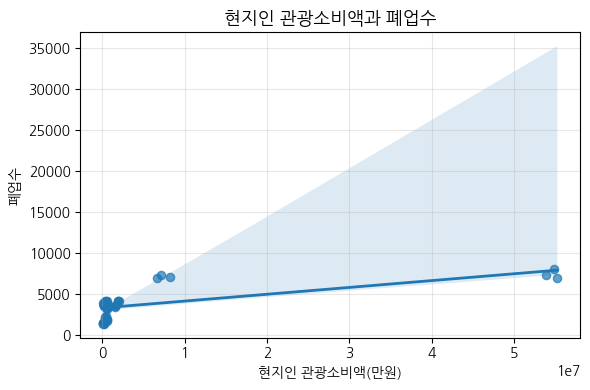

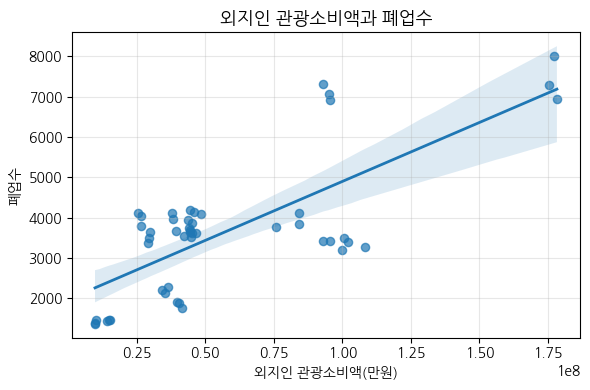

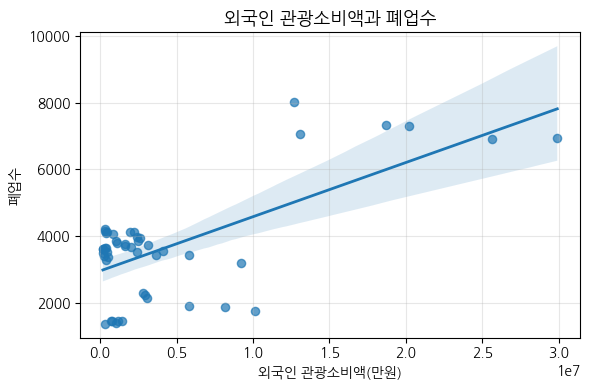

In [30]:
# ============================================================
# 1. 한글 폰트 설치
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum


# ============================================================
# 2. 라이브러리 불러오기
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns


# ============================================================
# 3. Matplotlib 폰트 캐시 초기화 및 한글 폰트 설정
# ============================================================

import os
import shutil

# Matplotlib 폰트 캐시 삭제
matplotlib_cache = os.path.expanduser('~/.cache/matplotlib')

if os.path.exists(matplotlib_cache):
    shutil.rmtree(matplotlib_cache)

# 나눔고딕 폰트 경로
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 폰트 등록
fm.fontManager.addfont(font_path)

# 폰트 이름 확인
font_name = fm.FontProperties(fname=font_path).get_name()

# 한글 폰트 적용
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

print("사용 폰트:", font_name)


# ============================================================
# 4. 분석에 사용할 관광소비 변수
# ============================================================

tourism_cols = [
    '현지인 관광소비액(만원)',
    '외지인 관광소비액(만원)',
    '외국인 관광소비액(만원)'
]

titles = [
    '현지인 관광소비액과 폐업수',
    '외지인 관광소비액과 폐업수',
    '외국인 관광소비액과 폐업수'
]


# ============================================================
# 5. 관광소비액 ↔ 폐업수 산점도 + 회귀선
# ============================================================

for col, title in zip(tourism_cols, titles):

    plt.figure(figsize=(6, 4))

    sns.regplot(
        data=df,
        x=col,
        y='폐업수',
        scatter_kws={
            's': 35,
            'alpha': 0.7
        },
        line_kws={
            'linewidth': 2
        }
    )

    plt.title(title, fontsize=13)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('폐업수', fontsize=10)

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

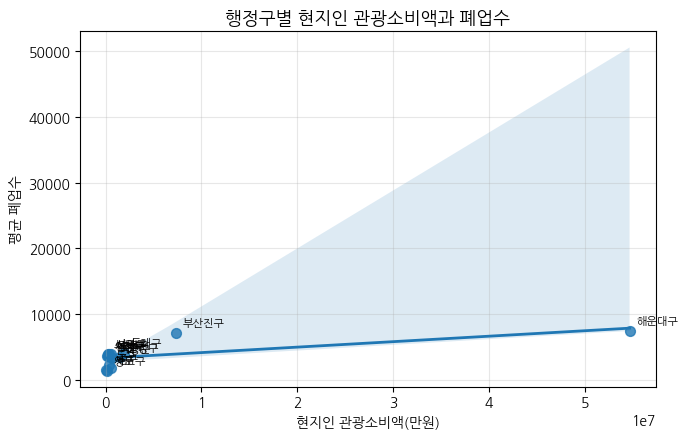

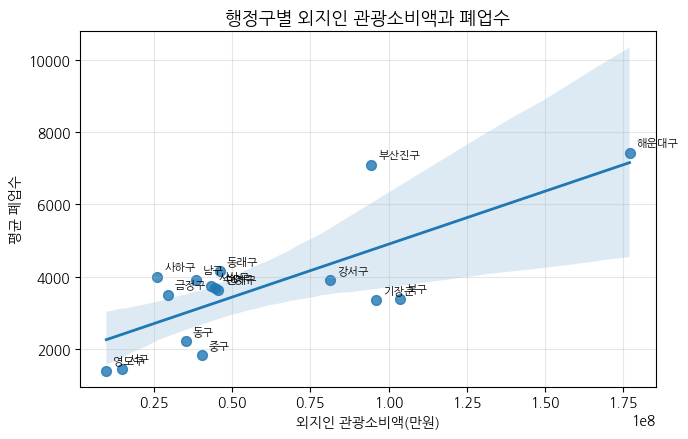

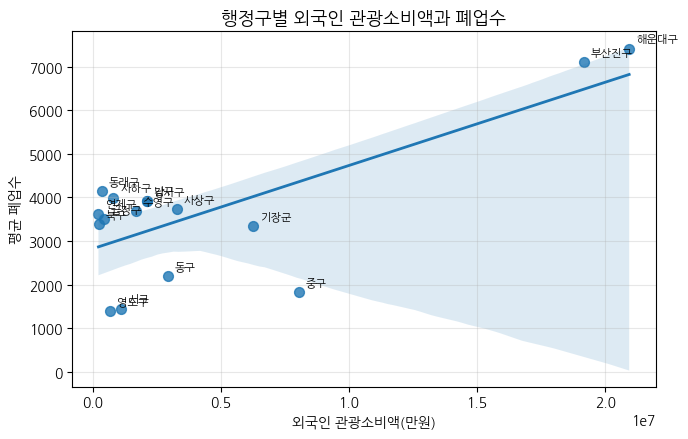

In [31]:
# ============================================================
# 행정구별 평균 관광소비액과 평균 폐업수
# ============================================================

# 행정구별 평균값 계산
district_mean = df.groupby('행정구')[
    [
        '현지인 관광소비액(만원)',
        '외지인 관광소비액(만원)',
        '외국인 관광소비액(만원)',
        '폐업수'
    ]
].mean().sort_values('폐업수', ascending=False)


# ============================================================
# 관광소비 유형별 그래프
# ============================================================

tourism_cols = [
    '현지인 관광소비액(만원)',
    '외지인 관광소비액(만원)',
    '외국인 관광소비액(만원)'
]

titles = [
    '행정구별 현지인 관광소비액과 폐업수',
    '행정구별 외지인 관광소비액과 폐업수',
    '행정구별 외국인 관광소비액과 폐업수'
]


for col, title in zip(tourism_cols, titles):

    plt.figure(figsize=(7, 4.5))

    sns.regplot(
        data=district_mean,
        x=col,
        y='폐업수',
        scatter_kws={
            's': 50,
            'alpha': 0.8
        },
        line_kws={
            'linewidth': 2
        }
    )

    # 각 점에 행정구 이름 표시
    for district, row in district_mean.iterrows():
        plt.annotate(
            district,
            (row[col], row['폐업수']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8
        )

    plt.title(title, fontsize=13)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('평균 폐업수', fontsize=10)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

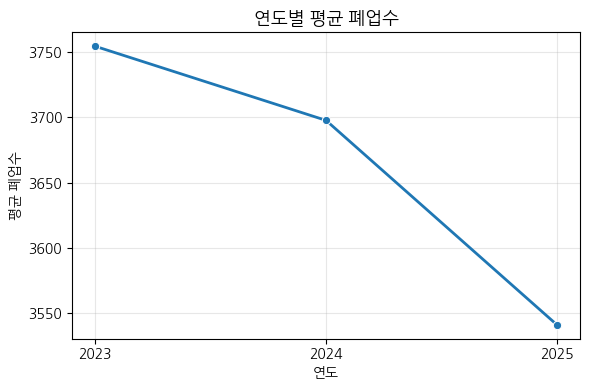

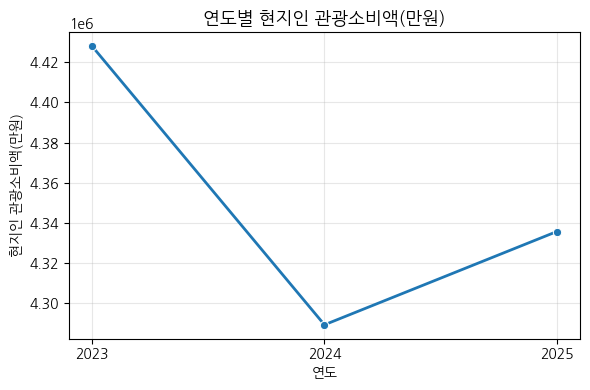

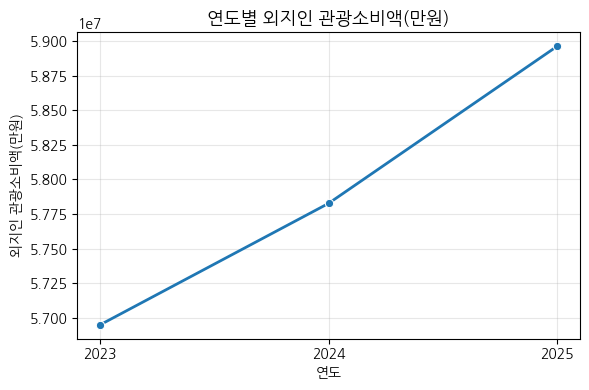

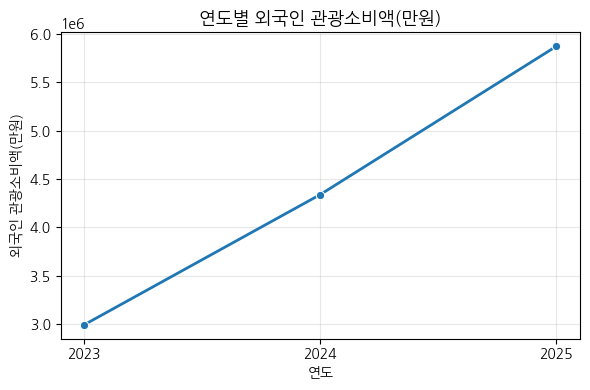

In [32]:
# ============================================================
# 연도별 관광소비액과 폐업수 변화
# ============================================================

# 연도별 평균값 계산
year_mean = df.groupby('연도')[
    [
        '현지인 관광소비액(만원)',
        '외지인 관광소비액(만원)',
        '외국인 관광소비액(만원)',
        '폐업수'
    ]
].mean().reset_index()


# ============================================================
# 1. 연도별 폐업수
# ============================================================

plt.figure(figsize=(6, 4))

sns.lineplot(
    data=year_mean,
    x='연도',
    y='폐업수',
    marker='o',
    linewidth=2
)

plt.title('연도별 평균 폐업수', fontsize=13)
plt.xlabel('연도')
plt.ylabel('평균 폐업수')

plt.xticks(year_mean['연도'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 2. 연도별 관광소비액
# ============================================================

for col in tourism_cols:

    plt.figure(figsize=(6, 4))

    sns.lineplot(
        data=year_mean,
        x='연도',
        y=col,
        marker='o',
        linewidth=2
    )

    plt.title(f'연도별 {col}', fontsize=13)
    plt.xlabel('연도')
    plt.ylabel(col)

    plt.xticks(year_mean['연도'])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

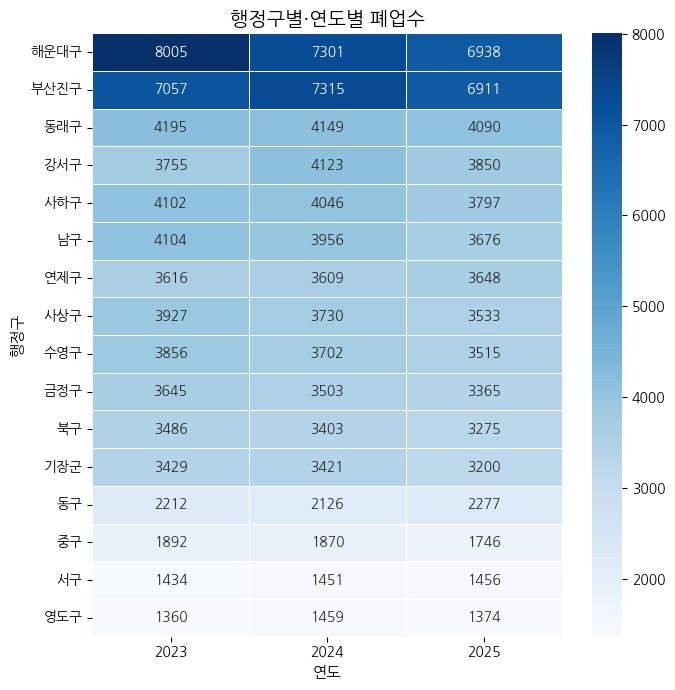

In [34]:
# ============================================================
# 행정구별·연도별 폐업수 히트맵
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# 행정구 × 연도 형태로 변환
pivot_closed = df.pivot(
    index='행정구',
    columns='연도',
    values='폐업수'
)

# 폐업수가 많은 행정구부터 정렬
pivot_closed = pivot_closed.sort_values(
    by=2025,
    ascending=False
)

# 그래프
plt.figure(figsize=(7, 7))

sns.heatmap(
    pivot_closed,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('행정구별·연도별 폐업수', fontsize=14)
plt.xlabel('연도', fontsize=11)
plt.ylabel('행정구', fontsize=11)

plt.tight_layout()
plt.show()

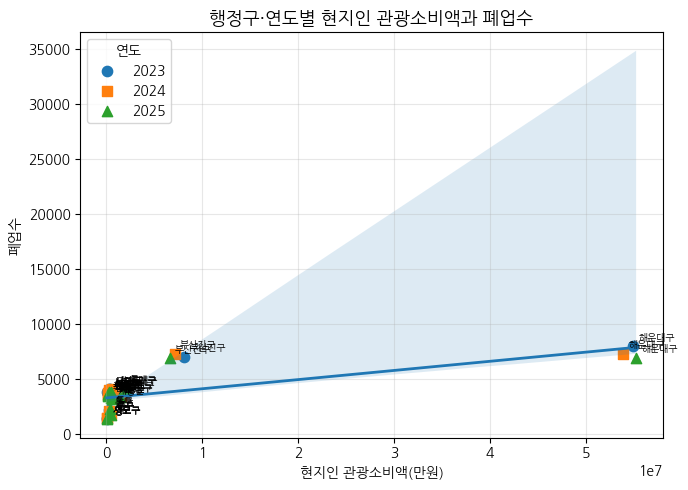

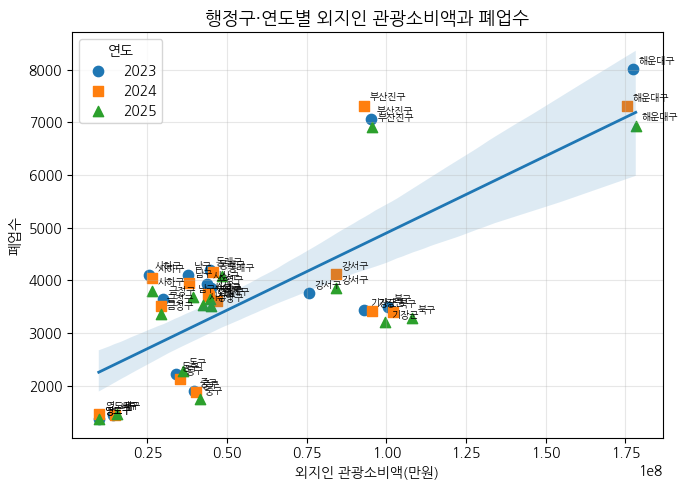

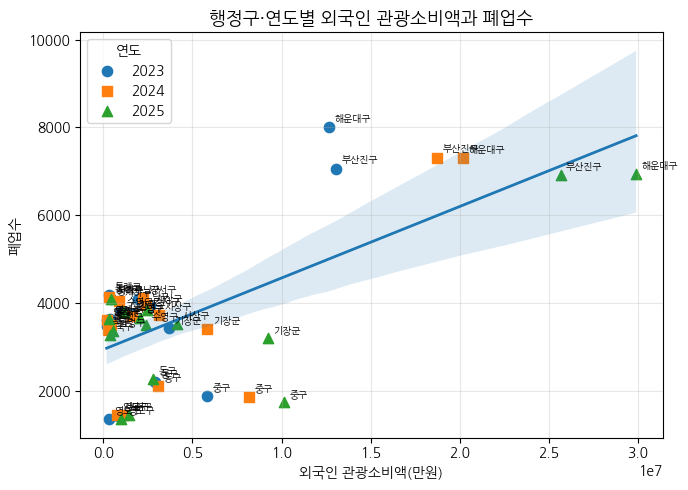

In [35]:
# ============================================================
# 행정구 + 연도별 관광소비액 ↔ 폐업수
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

tourism_cols = [
    '현지인 관광소비액(만원)',
    '외지인 관광소비액(만원)',
    '외국인 관광소비액(만원)'
]

titles = [
    '행정구·연도별 현지인 관광소비액과 폐업수',
    '행정구·연도별 외지인 관광소비액과 폐업수',
    '행정구·연도별 외국인 관광소비액과 폐업수'
]

# 연도별 구분
markers = {
    2023: 'o',
    2024: 's',
    2025: '^'
}

for col, title in zip(tourism_cols, titles):

    plt.figure(figsize=(7, 5))

    # 연도별로 따로 표시
    for year, marker in markers.items():

        temp = df[df['연도'] == year]

        plt.scatter(
            temp[col],
            temp['폐업수'],
            marker=marker,
            s=55,
            label=str(year)
        )

        # 행정구 이름 표시
        for _, row in temp.iterrows():

            plt.annotate(
                row['행정구'],
                (row[col], row['폐업수']),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=7
            )

    # 전체 데이터 회귀선
    sns.regplot(
        data=df,
        x=col,
        y='폐업수',
        scatter=False,
        line_kws={'linewidth': 2}
    )

    plt.title(title, fontsize=13)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('폐업수', fontsize=10)

    plt.legend(title='연도')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()